In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np


In [2]:
data = pd.read_excel('data.xlsx')
data.info()
data.head()



<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Education Level     5000 non-null   str  
 1   Specialization      5000 non-null   str  
 2   Skills              5000 non-null   str  
 3   Certifications      4404 non-null   str  
 4   CGPA/Percentage     5000 non-null   int64
 5   Recommended Career  5000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 234.5 KB


,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst
3,Bachelor's,Computer Science,Communication,NaN,75,Clerk
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant


In [3]:
#find out the unique values for education,specialization, recommended career
print(data['Education Level'].unique())
print(data['Specialization'].unique())
print(data['Recommended Career'].unique())


<StringArray>
['Bachelor's', 'Intermediate', 'Master's', 'Matric', 'PhD']
Length: 5, dtype: str
<StringArray>
[         'Finance',          'Science',         'Business',
 'Computer Science',             'Arts',       'Psychology',
         'Commerce',      'Engineering']
Length: 8, dtype: str
<StringArray>
[   'Business Analyst',   'Software Engineer',   'Financial Analyst',
               'Clerk',     'Sales Assistant',           'Professor',
 'Marketing Executive',   'Junior Accountant',    'School Counselor',
 'Data Entry Operator',  'Research Scientist',         'ML Engineer']
Length: 12, dtype: str


Going to use decision tree to predict career based on attributes given

In [4]:
# split data into train and test sets
# find out the amount of rows in the data
print(len(data))

#print count for each education level
print(data['Education Level'].value_counts())





5000
Education Level
Master's        1028
Bachelor's      1021
Matric          1014
Intermediate     973
PhD              964
Name: count, dtype: int64


In [5]:

# turn each skill in skills into separate columns for one hot encoding
skills = data['Skills'].str.split(',').apply(lambda x: [skill.strip() for skill in x])
all_skills = skills.explode().unique()
skills_df = pd.DataFrame(0, index=data.index, columns=all_skills)
for idx, skill_list in enumerate(skills):
    for skill in skill_list:
        skills_df.loc[idx, skill] = 1
data = pd.concat([data, skills_df], axis=1)
data.drop('Skills', axis=1, inplace=True)

#one hot encoding for education level, specialization, certifications
data = pd.get_dummies(data, columns=['Education Level', 'Specialization', 'Certifications'], drop_first=True)

#use label encoding for recommended career
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Recommended Career'] = le.fit_transform(data['Recommended Career'])


print(data.columns)



Index(['CGPA/Percentage', 'Recommended Career', 'Counseling', 'MS Office',
       'Machine Learning', 'Accounting', 'SQL', 'Data Analysis',
       'Communication', 'Financial Analysis', 'Python', 'Marketing',
       'Education Level_Intermediate', 'Education Level_Master's',
       'Education Level_Matric', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Certifications_CFA Level 1',
       'Certifications_Creative Writing', 'Certifications_Digital Marketing',
       'Certifications_Google Data Analytics',
       'Certifications_Mental Health Basics', 'Certifications_Tally ERP'],
      dtype='str')


In [6]:
data.head()

,CGPA/Percentage,Recommended Career,Counseling,MS Office,Machine Learning,Accounting,SQL,Data Analysis,Communication,Financial Analysis,...,Specialization_Engineering,Specialization_Finance,Specialization_Psychology,Specialization_Science,Certifications_CFA Level 1,Certifications_Creative Writing,Certifications_Digital Marketing,Certifications_Google Data Analytics,Certifications_Mental Health Basics,Certifications_Tally ERP
0,67,0,1,1,1,0,0,0,0,0,...,False,True,False,False,False,False,False,False,False,True
1,67,11,0,1,0,1,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False
2,90,3,0,0,0,1,1,1,0,0,...,False,False,False,False,False,False,False,False,True,False
3,75,1,0,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
4,83,9,0,0,0,0,0,1,0,0,...,False,False,False,False,False,False,False,False,False,True


In [7]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   CGPA/Percentage                       5000 non-null   int64
 1   Recommended Career                    5000 non-null   int64
 2   Counseling                            5000 non-null   int64
 3   MS Office                             5000 non-null   int64
 4   Machine Learning                      5000 non-null   int64
 5   Accounting                            5000 non-null   int64
 6   SQL                                   5000 non-null   int64
 7   Data Analysis                         5000 non-null   int64
 8   Communication                         5000 non-null   int64
 9   Financial Analysis                    5000 non-null   int64
 10  Python                                5000 non-null   int64
 11  Marketing                             5000 non-null   

In [8]:
#create decision tree to predict recommended career
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_fscore_support

# Split data
X = data.drop('Recommended Career', axis=1)
y = data['Recommended Career']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

for depth in range(8, 13):  # 8–12
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    # Get macro F1 directly
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")

#append a result of a descision tree with no max depth
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
_, _, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro', zero_division=0
)
results.append(('No max depth', macro_f1))

# Best depth
best_depth, best_score = max(results, key=lambda x: x[1])

print(f"\nBest depth: {best_depth}")
print(f"Best Macro F1: {best_score:.4f}")


Depth 8 → Macro F1: 0.0696
Depth 9 → Macro F1: 0.0694
Depth 10 → Macro F1: 0.0828
Depth 11 → Macro F1: 0.0815
Depth 12 → Macro F1: 0.0846

Best depth: No max depth
Best Macro F1: 0.0891


                     precision    recall  f1-score   support

   Business Analyst       0.10      0.10      0.10        79
              Clerk       0.11      0.13      0.12        85
Data Entry Operator       0.09      0.10      0.09        83
  Financial Analyst       0.11      0.09      0.10        79
  Junior Accountant       0.08      0.09      0.08        80
        ML Engineer       0.07      0.06      0.06        85
Marketing Executive       0.08      0.07      0.07        97
          Professor       0.07      0.07      0.07        83
 Research Scientist       0.07      0.10      0.08        71
    Sales Assistant       0.10      0.09      0.09        87
   School Counselor       0.08      0.07      0.07        91
  Software Engineer       0.12      0.11      0.12        80

           accuracy                           0.09      1000
          macro avg       0.09      0.09      0.09      1000
       weighted avg       0.09      0.09      0.09      1000



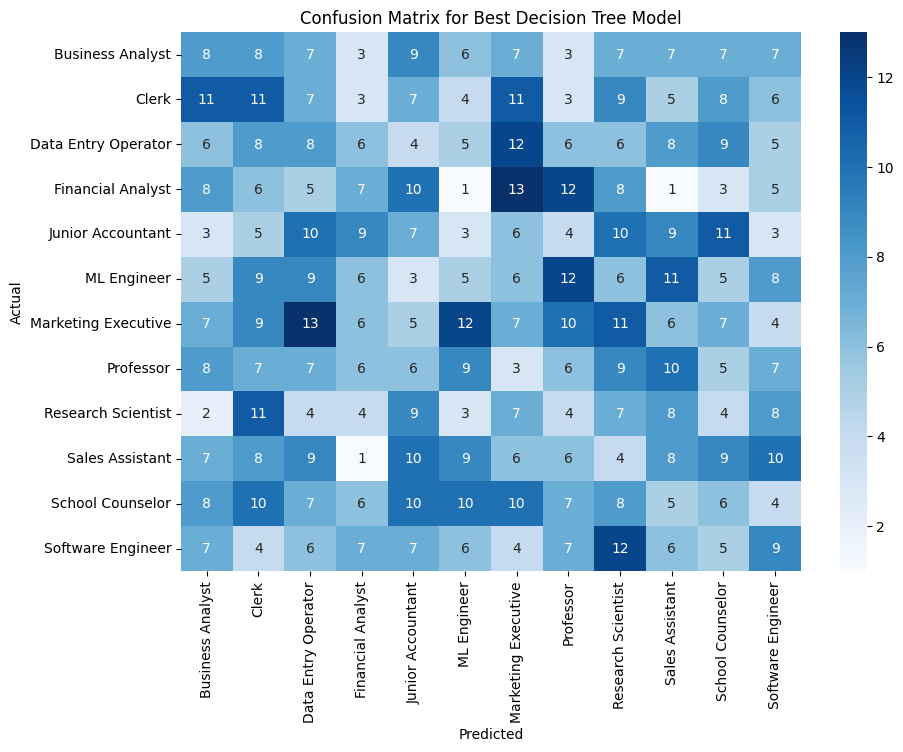

In [9]:
# print the classification report for the best model
from sklearn.metrics import classification_report
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42) if best_depth != 'No max depth' else DecisionTreeClassifier(random_state=42)
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

#print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Best Decision Tree Model')
plt.show()  

In [10]:
#implement random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
_, _, macro_f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average='macro', zero_division=0
)
print(f"Random Forest Macro F1: {macro_f1_rf:.4f}")

Random Forest Macro F1: 0.0822


Random forest model is worst than decision tree, will need to decrease columns and group them

In [11]:
print(data.columns)
#print career recommendations unique values
print(le.classes_)


Index(['CGPA/Percentage', 'Recommended Career', 'Counseling', 'MS Office',
       'Machine Learning', 'Accounting', 'SQL', 'Data Analysis',
       'Communication', 'Financial Analysis', 'Python', 'Marketing',
       'Education Level_Intermediate', 'Education Level_Master's',
       'Education Level_Matric', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Certifications_CFA Level 1',
       'Certifications_Creative Writing', 'Certifications_Digital Marketing',
       'Certifications_Google Data Analytics',
       'Certifications_Mental Health Basics', 'Certifications_Tally ERP'],
      dtype='str')
['Business Analyst' 'Clerk' 'Data Entry Operator' 'Financial Analyst'
 'Junior Accountant' 'ML Engineer' 'Marketing Executive' 'Professor'
 'Research Scientist' 'Sales Assistant' 'School Coun

In [12]:
from sklearn.preprocessing import LabelEncoder
data['Recommended Career'] = le.inverse_transform(data['Recommended Career'])

def map_career(career):
    if career in ['ML Engineer', 'Software Engineer', 'Data Entry Operator', 'Research Scientist']:
        return 'Tech'
    
    elif career in ['Business Analyst', 'Financial Analyst', 'Junior Accountant']:
        return 'Business/Finance'
    
    elif career in ['Marketing Executive', 'Sales Assistant']:
        return 'Marketing/Sales'
    
    elif career in ['Professor', 'School Counselor']:
        return 'Education'
    
    elif career in ['Clerk']:
        return 'Admin'
    
    else:
        return 'Other'  

# Apply grouping
data['Recommended Career'] = data['Recommended Career'].apply(map_career)



# Encode
le = LabelEncoder()
data['Recommended Career'] = le.fit_transform(data['Recommended Career'])

# Verify
print(le.classes_)

['Admin' 'Business/Finance' 'Education' 'Marketing/Sales' 'Tech']


In [13]:


X = data.drop('Recommended Career', axis=1)
y = data['Recommended Career']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

# Test depths 8–12
for depth in range(8, 13):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")

# Test no max depth
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

_, _, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro', zero_division=0
)

results.append(("No max depth", macro_f1))
print(f"No max depth → Macro F1: {macro_f1:.4f}")

# Pick best model setting
best_depth, best_score = max(results, key=lambda x: x[1])

print(f"\nBest depth: {best_depth}")
print(f"Best Macro F1: {best_score:.4f}")


Depth 8 → Macro F1: 0.1454
Depth 9 → Macro F1: 0.1508
Depth 10 → Macro F1: 0.1529
Depth 11 → Macro F1: 0.1639
Depth 12 → Macro F1: 0.1843
No max depth → Macro F1: 0.2054

Best depth: No max depth
Best Macro F1: 0.2054


Although I got an increase in accuracy, its because there are less classes so if i randomly guess i have a 20% and the model is guessing at 20% so it's not better than random

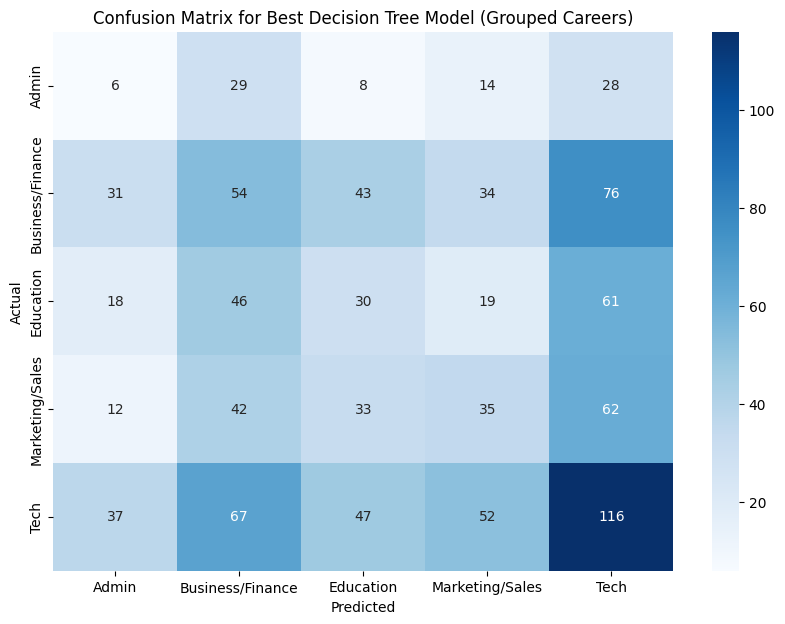

In [14]:
# plot confusion matrix for best model
best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42) if best_depth != 'No max depth' else DecisionTreeClassifier(random_state=42)
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Best Decision Tree Model (Grouped Careers)')
plt.show()

it looks like most of the classes predict tech, I need to figure out why and see if i can change or remove that variable

In [ ]:
#implement random forest tree with class weight balanced
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
_, _, macro_f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average='macro', zero_division=0
)
print(f"Random Forest Macro F1: {macro_f1_rf:.4f}")

Random Forest Macro F1: 0.1954


In [16]:
#use only education level and specialization to predict recommended career
print(data.columns)

#combine intermediate and matric columns into highschool column
data['Education Level_High School'] = data['Education Level_Intermediate'] | data['Education Level_Matric']
data.drop(['Education Level_Intermediate', 'Education Level_Matric'], axis=1, inplace=True)
print(data.columns)



Index(['CGPA/Percentage', 'Recommended Career', 'Counseling', 'MS Office',
       'Machine Learning', 'Accounting', 'SQL', 'Data Analysis',
       'Communication', 'Financial Analysis', 'Python', 'Marketing',
       'Education Level_Intermediate', 'Education Level_Master's',
       'Education Level_Matric', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Certifications_CFA Level 1',
       'Certifications_Creative Writing', 'Certifications_Digital Marketing',
       'Certifications_Google Data Analytics',
       'Certifications_Mental Health Basics', 'Certifications_Tally ERP'],
      dtype='str')
Index(['CGPA/Percentage', 'Recommended Career', 'Counseling', 'MS Office',
       'Machine Learning', 'Accounting', 'SQL', 'Data Analysis',
       'Communication', 'Financial Analysis', 'Pyth

In [17]:
data['Education Level_Bachelors'] = (
    (data['Education Level_High School'] == 0) &
    (data["Education Level_Master's"] == 0) &
    (data['Education Level_PhD'] == 0)
).astype(int)

In [22]:


#print count for each education level
print(data['Education Level_High School'].value_counts())
print(data['Education Level_Bachelors'].value_counts())
print(data["Education Level_Master's"].value_counts())
print(data['Education Level_PhD'].value_counts())

skills = [
    'Counseling', 'MS Office', 'Machine Learning', 'Accounting',
    'SQL', 'Data Analysis', 'Communication', 'Financial Analysis',
    'Python', 'Marketing'
]

data.rename(columns={col: f"Skills_{col}" for col in skills}, inplace=True)
print(data.columns)

Education Level_High School
False    3013
True     1987
Name: count, dtype: int64
Education Level_Bachelors
0    3979
1    1021
Name: count, dtype: int64
Education Level_Master's
False    3972
True     1028
Name: count, dtype: int64
Education Level_PhD
False    4036
True      964
Name: count, dtype: int64
Index(['CGPA/Percentage', 'Recommended Career', 'Skills_Counseling',
       'Skills_MS Office', 'Skills_Machine Learning', 'Skills_Accounting',
       'Skills_SQL', 'Skills_Data Analysis', 'Skills_Communication',
       'Skills_Financial Analysis', 'Skills_Python', 'Skills_Marketing',
       'Education Level_Master's', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Certifications_CFA Level 1',
       'Certifications_Creative Writing', 'Certifications_Digital Marketing',
       'Certi

In [ ]:
# use only degree, certifications, and specialization to predict recommended career with decision tree
feature_cols = [
    col for col in data.columns
    if col.startswith('Education Level_') or col.startswith('Specialization_') or col.startswith('Certifications_')
]

X = data[feature_cols]
y = data['Recommended Career']

y = data['Recommended Career']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
results = []
print(X.columns)
 # implement decision tree with only education level and specialization
for depth in range(8, 13):  # 8–12
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")


Index(['Education Level_Master's', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Certifications_CFA Level 1',
       'Certifications_Creative Writing', 'Certifications_Digital Marketing',
       'Certifications_Google Data Analytics',
       'Certifications_Mental Health Basics', 'Certifications_Tally ERP',
       'Education Level_High School', 'Education Level_Bachelors'],
      dtype='str')
Depth 8 → Macro F1: 0.1620
Depth 9 → Macro F1: 0.1873
Depth 10 → Macro F1: 0.1655
Depth 11 → Macro F1: 0.1797
Depth 12 → Macro F1: 0.1656


In [20]:
# use only degree and specialization to predict recommended career with decision tree
feature_cols1 = [
    col for col in data.columns
    if col.startswith('Education Level_') or col.startswith('Specialization_')
]

X = data[feature_cols1]
y = data['Recommended Career']

y = data['Recommended Career']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
results = []
print(X.columns)
 # implement decision tree with only education level and specialization
for depth in range(8, 13):  # 8–12
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")

Index(['Education Level_Master's', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Education Level_High School',
       'Education Level_Bachelors'],
      dtype='str')
Depth 8 → Macro F1: 0.1538
Depth 9 → Macro F1: 0.1645
Depth 10 → Macro F1: 0.1674
Depth 11 → Macro F1: 0.1674
Depth 12 → Macro F1: 0.1674


In [21]:
# use only degree and specialization and skills to predict recommended career with decision tree
feature_cols = [
    col for col in data.columns
    if col.startswith('Education Level_') or col.startswith('Specialization_') or col.startswith('Skills_')
]

X = data[feature_cols]
y = data['Recommended Career']

y = data['Recommended Career']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
results = []
print(X.columns)
 # implement decision tree with only education level and specialization
for depth in range(8, 13):  # 8–12
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append((depth, macro_f1))
    print(f"Depth {depth} → Macro F1: {macro_f1:.4f}")

Index(['Skills_Counseling', 'Skills_MS Office', 'Skills_Machine Learning',
       'Skills_Accounting', 'Skills_SQL', 'Skills_Data Analysis',
       'Skills_Communication', 'Skills_Financial Analysis', 'Skills_Python',
       'Skills_Marketing', 'Education Level_Master's', 'Education Level_PhD',
       'Specialization_Business', 'Specialization_Commerce',
       'Specialization_Computer Science', 'Specialization_Engineering',
       'Specialization_Finance', 'Specialization_Psychology',
       'Specialization_Science', 'Education Level_High School',
       'Education Level_Bachelors'],
      dtype='str')
Depth 8 → Macro F1: 0.1572
Depth 9 → Macro F1: 0.1677
Depth 10 → Macro F1: 0.1666
Depth 11 → Macro F1: 0.1808
Depth 12 → Macro F1: 0.1760


Couldn't find any combination or grouping of features to get a accuracy result that was better than random. Could be because of the data set being synthetic